# 固定済み before / after ペアの部位別見た目解析

`video_before_after_pair.ipynb` で固定した `selected_pair.json` を使い、眉・上まぶた・唇・頬・額の記述的特徴量を比較します。

この notebook は **好印象・美しさ・若々しさの総合点を付けません**。Lab色、周囲皮膚とのコントラスト、頬の色ばらつき・明部率などを測り、人による印象評価と後で照合するための解析です。

入力画像・ROI・実装内容からfingerprintを作り、異なるrankの解析結果は別フォルダに保存します。既存結果を別入力として上書きしません。


In [1]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
marker = Path('analysis/analyze_appearance.py')
if (cwd / marker).is_file():
    REPO_ROOT = cwd
elif cwd.name == 'notebooks' and (cwd.parent / marker).is_file():
    REPO_ROOT = cwd.parent
    os.chdir(REPO_ROOT)
else:
    raise RuntimeError(f'ikiikimake のリポジトリ直下または notebooks/ から実行してください: current={cwd}')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('repo root:', Path.cwd())


repo root: C:\Users\mail\work\ikiikimake


## 設定


In [2]:
VIDEO = Path('makeup0923.mp4')
OUTPUT = Path('outputs') / VIDEO.stem
SELECTED = OUTPUT / 'selected_pair.json'
APPEARANCE_ROOT = OUTPUT / 'appearance_selected_pair'

if not SELECTED.is_file():
    raise FileNotFoundError(
        f'固定済みペアがありません: {SELECTED}. '
        '先に video_before_after_pair.ipynb で候補を固定してください。'
    )

print('selected pair   :', SELECTED)
print('appearance root :', APPEARANCE_ROOT)


selected pair   : outputs\makeup0923\selected_pair.json
appearance root : outputs\makeup0923\appearance_selected_pair


## 解析

元画像・ROI成果物のSHA-256を検証してから解析します。測定対象は元解像度の画素で、解析のためのリサイズや平滑化はしません。


In [3]:
from analysis.analyze_appearance import analyze_selected_appearance, summary_html
from IPython.display import HTML, display

summary = analyze_selected_appearance(SELECTED, APPEARANCE_ROOT)
RUN_DIR = Path(summary['output_dir'])

print('appearance run:', RUN_DIR)
display(HTML(summary_html(summary, include_images=False)))


appearance run: C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c


指標,単位,before,after,差,状態
画面左眉の相対明度コントラスト,L*,28.70,32.87,+4.17,測定値あり・要目視
画面左上まぶた外側帯の相対明度コントラスト,L*,26.84,45.83,+18.99,測定値あり・要目視
画面右眉の相対明度コントラスト,L*,20.84,30.35,+9.51,測定値あり・要目視
画面右上まぶた外側帯の相対明度コントラスト,L*,24.98,38.76,+13.78,測定値あり・要目視
画面左目の下の細かな質感コントラスト（中央値）,局所L*比 %,0.62,1.25,+0.62,測定値あり・要目視
画面左目の下の細かな質感コントラスト（p90）,局所L*比 %,1.94,5.04,+3.11,測定値あり・要目視
画面右目の下の細かな質感コントラスト（中央値）,局所L*比 %,0.57,0.62,+0.05,測定値あり・要目視
画面右目の下の細かな質感コントラスト（p90）,局所L*比 %,3.48,5.25,+1.77,測定値あり・要目視
唇と周囲皮膚のa*差,a*,13.38,19.44,+6.06,測定値あり・要目視
唇と周囲皮膚のLab色差,ΔE*ab（CIE76）,16.40,23.33,+6.94,測定値あり・要目視


## 測定領域と変化を目視確認

自動値を読む前に、ROIが眉・上まぶた・唇・頬・額の意図した場所に入っているか、髪・手・強い影が混ざっていないか確認します。


appearance_rois.png


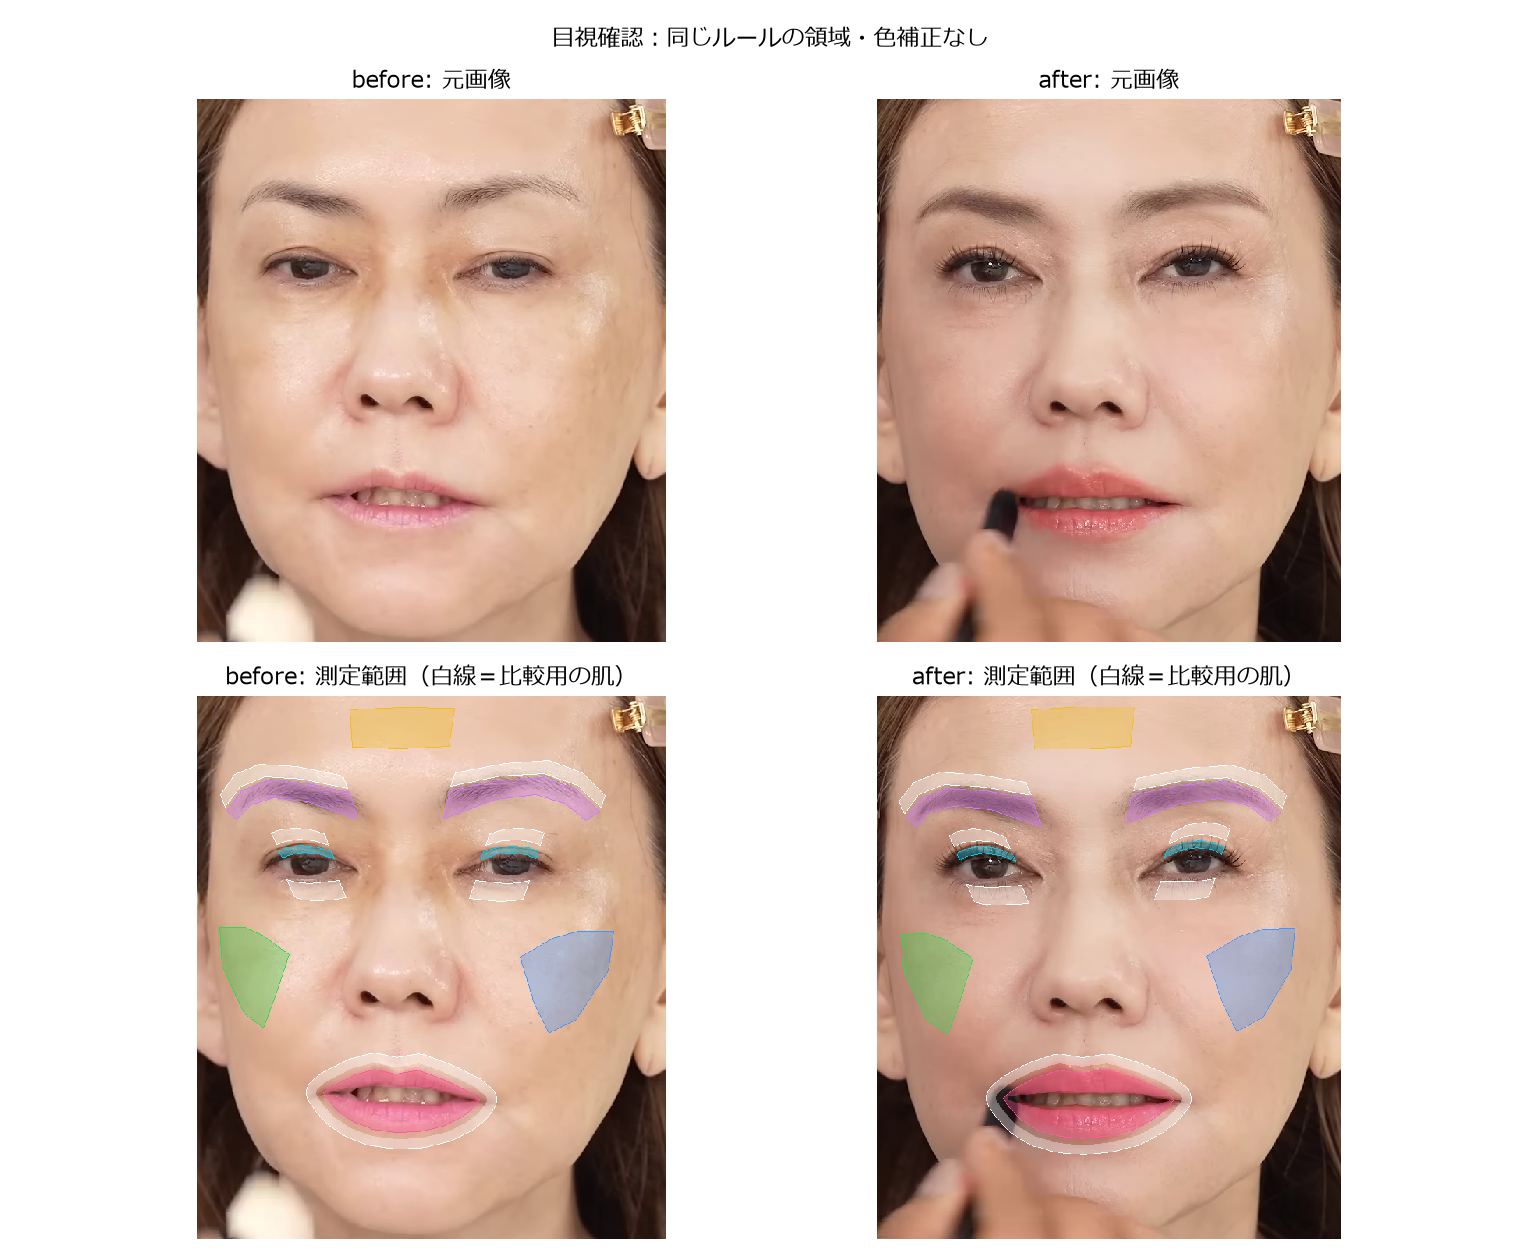

region_samples.png


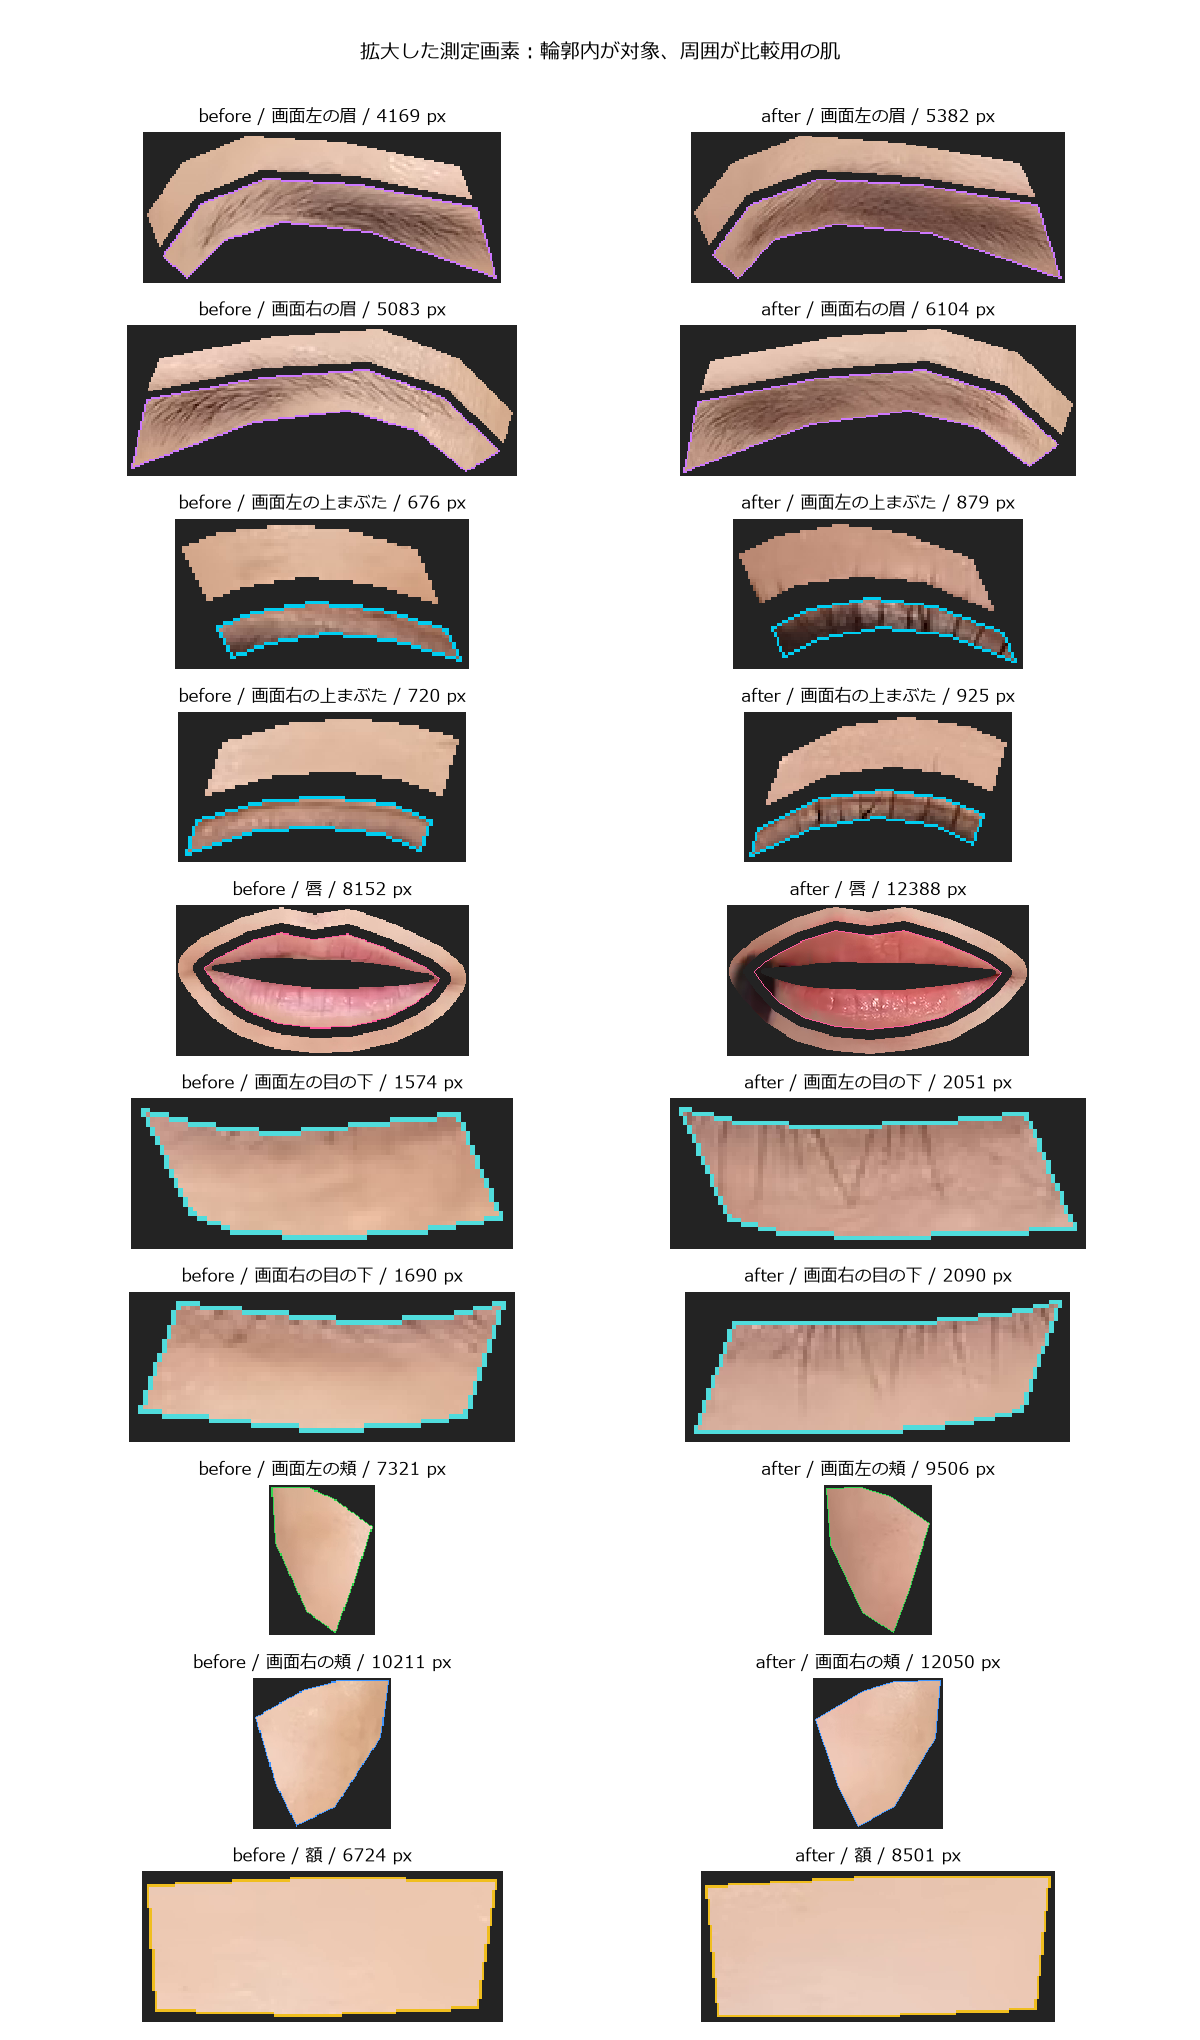

feature_changes.png


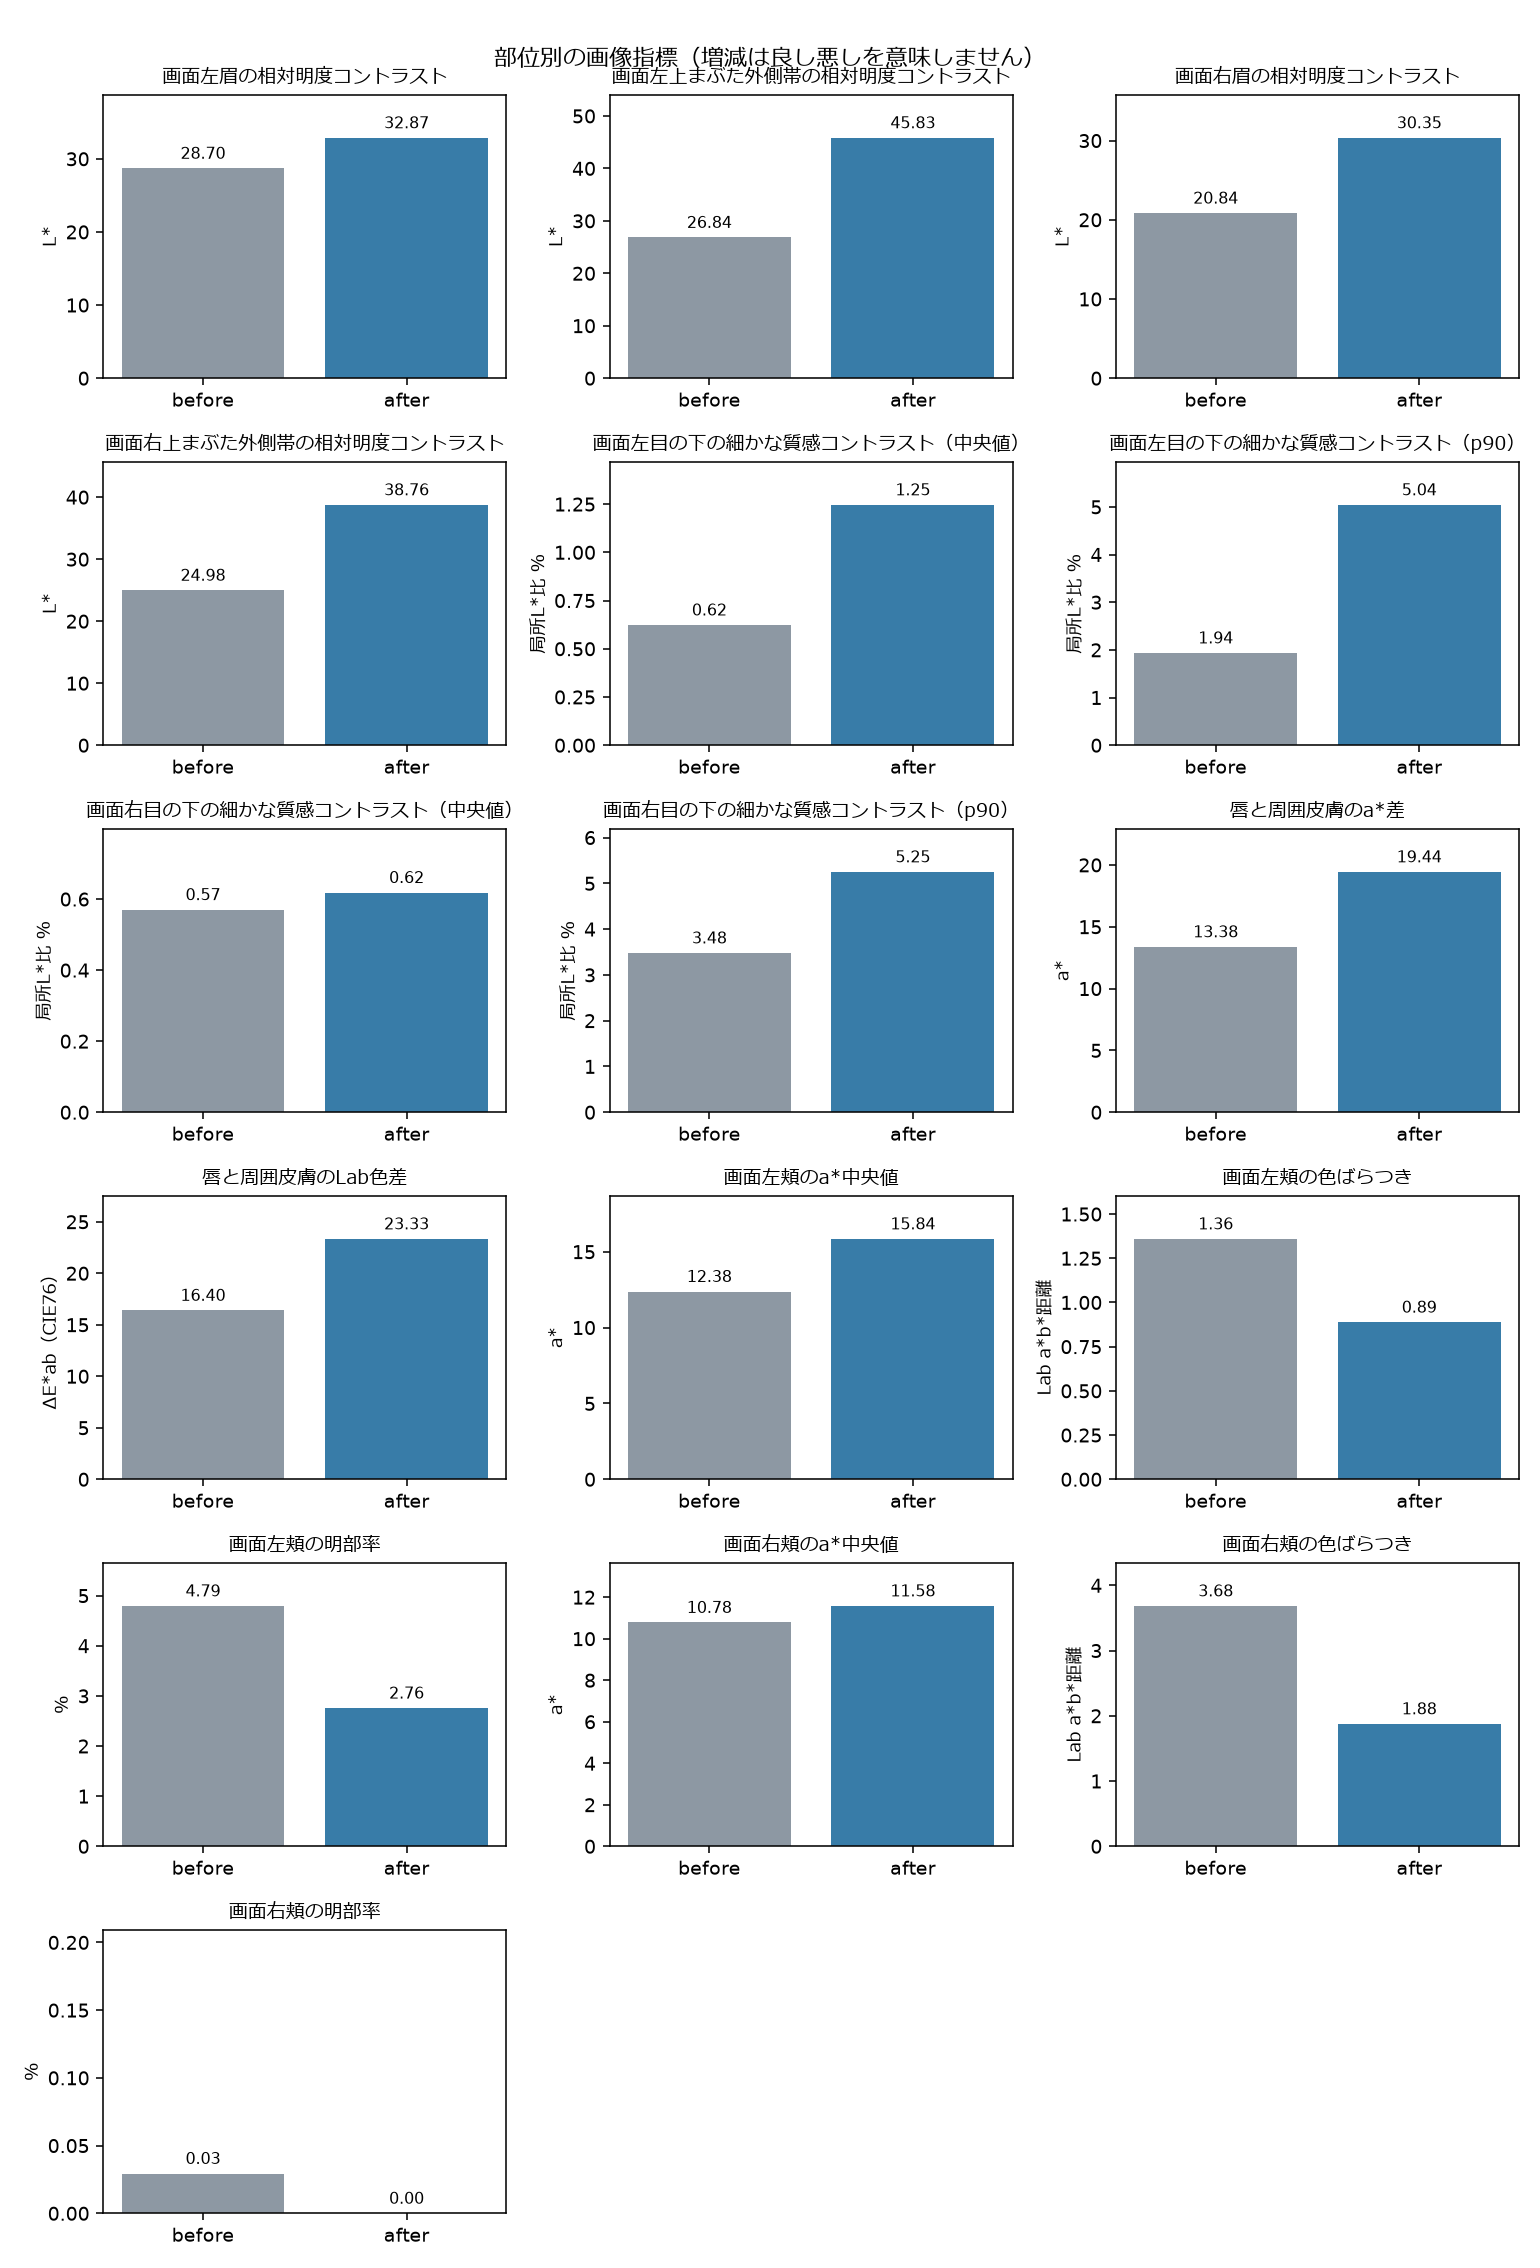

In [4]:
from IPython.display import Image as IPImage

for name in ('appearance_rois.png', 'region_samples.png', 'feature_changes.png'):
    path = RUN_DIR / name
    if not path.is_file():
        raise FileNotFoundError(path)
    print(name)
    display(IPImage(filename=str(path)))


## 生成ファイル


In [5]:
for name in (
    'report.html', 'feature_summary.json', 'feature_deltas.csv',
    'appearance_rois.png', 'region_samples.png', 'feature_changes.png',
    'before_feature_masks.npz', 'after_feature_masks.npz',
):
    path = RUN_DIR / name
    if not path.is_file():
        raise FileNotFoundError(path)
    print(path)


C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\report.html
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\feature_summary.json
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\feature_deltas.csv
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\appearance_rois.png
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\region_samples.png
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\feature_changes.png
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\before_feature_masks.npz
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\789ba10b33479d6c\after_feature_masks.npz
